In [32]:
import lightkurve as lk 
import matplotlib.pyplot as plt 
import numpy as np 

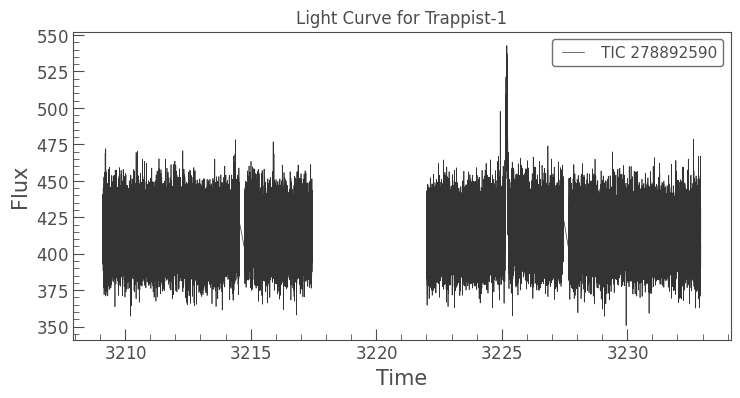

In [33]:
# Ask User for the Star's Name and Mission Name
star_name = input("Enter the name of the star (e.g., Kepler-10,TRAPPIST-1, HD 209458):") 
mission_name = input("Enter the mission name (e.g.,Kepler, K2, SPOC,TESS):")
# Search for the star's light curve data
search_result = lk.search_lightcurve(star_name, author=mission_name)
if len(search_result) == 0:
    print(f"No light curve data found for {star_name}. Please check the name and try again.")
else:
    # Download the light curve data
    lc = search_result[0].download()
    # Plot the light curve
    lc.plot()
    plt.title(f"Light Curve for {star_name}")
    plt.xlabel("Time")
    plt.ylabel("Flux")
    plt.show()


In [34]:
# Flatten the light curve
flat_lc = lc.flatten(window_length=401)

# Plot the flattened version
flat_lc.plot()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

In [35]:
# Run the Box Least Squares (BLS) algorithm
a=float(input("Enter the minimum period to search for (e.g., 0.5): "))
b=float(input("Enter the maximum period to search for (e.g., 10): "))
periodogram = flat_lc.to_periodogram(method='bls', period=np.arange(a, b, 0.001))

# Find the best orbital period
best_period = periodogram.period_at_max_power
print(f"Potential Planet Period: {best_period}")

# Fold the data (overlay all transits to see the shape)
folded_lc = flat_lc.fold(period=best_period)
folded_lc.plot()

Potential Planet Period: 3.079999999999991 d


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

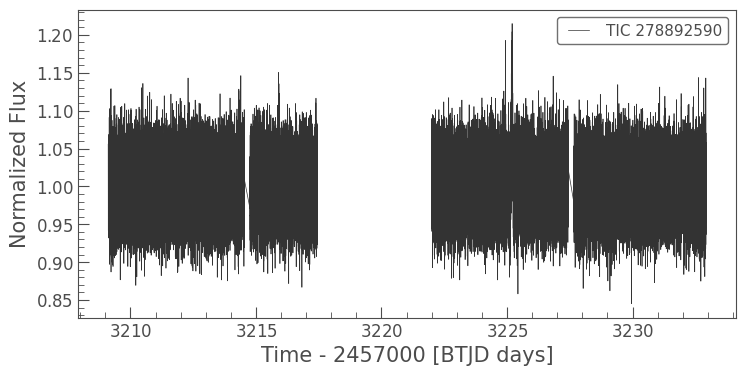

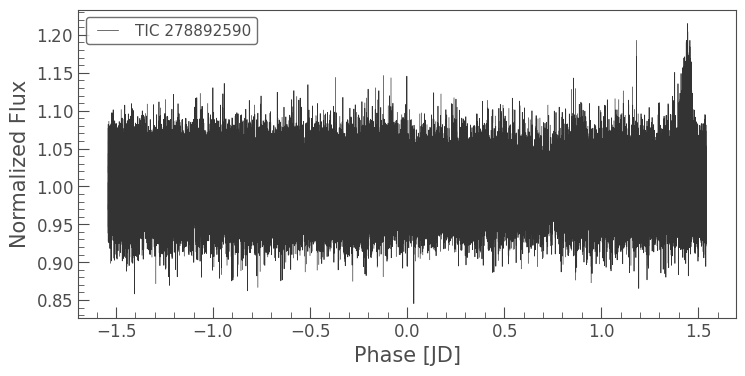

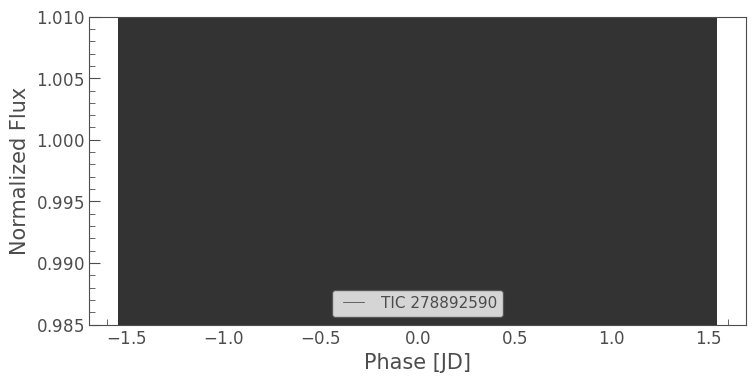

The detected orbital period is: 3.079999999999991 d days


In [36]:
best_period = periodogram.period_at_max_power
folded_lc = flat_lc.fold(period=best_period)
folded_lc.plot()
plt.ylim(0.985, 1.01) #Zoom on the transit for better visibility
plt.show()
# This line finds the number
best_period = periodogram.period_at_max_power

# This line "runs" the output so you can read it
print(f"The detected orbital period is: {best_period} days")

In [37]:
import pandas as pd
Strip_Period=best_period.value
data={"Period days":[Strip_Period]}
df=pd.DataFrame(data)
print(df)
df.to_csv("Detected_Planet_Period.csv", index=False)


   Period days
0         3.08
